# Задание Ultra Pro — вариант на PyTorch

Используется база **«Пассажиры автобуса»**.

Задача: классифицировать изображение на два класса:
- входящий пассажир;
- выходящий пассажир.

Цель: получить точность на тестовой выборке не ниже 85%.


In [1]:

import os
import zipfile

import gdown

import numpy as np
from PIL import Image

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

%matplotlib inline


In [2]:
# Фиксируем случайность
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(1)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Устройство:', device)


Устройство: cpu


In [3]:

DATA_URL = 'https://storage.yandexcloud.net/aiueducation/Content/base/l4/bus.zip'
ARCHIVE_NAME = 'bus.zip'
BASE_DIR = '/content'

if not os.path.exists(ARCHIVE_NAME):
    gdown.download(DATA_URL, ARCHIVE_NAME, quiet=True)

with zipfile.ZipFile(ARCHIVE_NAME, 'r') as archive:
    archive.extractall(BASE_DIR)

print('База загружена')


База загружена


In [4]:
class BusNet(nn.Module):
    def __init__(self, img_height=120, img_width=80):
        super().__init__()

        # Вход 1
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(img_height * img_width, 256),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        return self.net(x)


In [5]:
class BusPassengerTorch:
    def __init__(self, epochs=40, batch_size=32, img_height=120, img_width=80, learning_rate=0.001, patience=5):
        self.epochs = epochs
        self.batch_size = batch_size
        self.img_height = img_height
        self.img_width = img_width
        self.learning_rate = learning_rate
        self.patience = patience

        self.class_names = ['Входящий', 'Выходящий']
        self.class_to_label = {'Входящий': 0, 'Выходящий': 1}
        self.model = None

    # загрузка изображений из папок
    def load_dataset(self):
        x_data = []
        y_data = []

        for class_name in self.class_names:
            class_dir = os.path.join(BASE_DIR, class_name)

            if not os.path.isdir(class_dir):
                raise FileNotFoundError(f'Папка не найдена: {class_dir}')

            for file_name in sorted(os.listdir(class_dir)):
                img_path = os.path.join(class_dir, file_name)

                if not os.path.isfile(img_path):
                    continue

                try:
                    # Открываем изображение
                    img = Image.open(img_path).convert('L')
                    img = img.resize((self.img_width, self.img_height))

                    img_array = np.array(img, dtype='float32') / 255.0
                    img_array = np.expand_dims(img_array, axis=0)

                    x_data.append(img_array)
                    y_data.append(self.class_to_label[class_name])

                except Exception as error:
                    print('Файл пропущен:', img_path, error)

        x_data = np.array(x_data, dtype='float32')
        y_data = np.array(y_data, dtype='int64')

        print('Размер x_data:', x_data.shape)
        print('Размер y_data:', y_data.shape)
        print('Количество по классам:', np.unique(y_data, return_counts=True))

        return x_data, y_data

    # разбиение на обучающую, проверочную, тестовую выборки
    def load_data(self):
        x_data, y_data = self.load_dataset()

        x_train_val, x_test, y_train_val, y_test = train_test_split(
            x_data,
            y_data,
            test_size=0.2,
            random_state=SEED,
            stratify=y_data
        )

        x_train, x_val, y_train, y_val = train_test_split(
            x_train_val,
            y_train_val,
            test_size=0.25,  # 0.25 от 0.8 = 0.2 от всего набора
            random_state=SEED,
            stratify=y_train_val
        )

        return x_train, y_train, x_val, y_val, x_test, y_test

    # создание загрузчика данных
    def make_loader(self, x, y, shuffle=False):
        x_tensor = torch.tensor(x, dtype=torch.float32)
        y_tensor = torch.tensor(y, dtype=torch.long)

        dataset = TensorDataset(x_tensor, y_tensor)

        return DataLoader(
            dataset,
            batch_size=self.batch_size,
            shuffle=shuffle
        )

    # создание модели
    def create_model(self):
        self.model = BusNet(
            img_height=self.img_height,
            img_width=self.img_width
        ).to(device)

        return self.model

    # один проход по выборке
    def run_epoch(self, loader, criterion, optimizer=None):
        is_train = optimizer is not None

        if is_train:
            self.model.train()
        else:
            self.model.eval()

        total_loss = 0
        total_correct = 0
        total_count = 0

        with torch.set_grad_enabled(is_train):
            for x_batch, y_batch in loader:
                x_batch = x_batch.to(device)
                y_batch = y_batch.to(device)

                if is_train:
                    optimizer.zero_grad()

                outputs = self.model(x_batch)
                loss = criterion(outputs, y_batch)

                if is_train:
                    loss.backward()
                    optimizer.step()

                predictions = torch.argmax(outputs, dim=1)
                total_correct += (predictions == y_batch).sum().item()
                total_loss += loss.item() * x_batch.size(0)
                total_count += x_batch.size(0)

        avg_loss = total_loss / total_count
        avg_accuracy = total_correct / total_count

        return avg_loss, avg_accuracy

    # обучение модели
    def train_model(self):
        x_train, y_train, x_val, y_val, x_test, y_test = self.load_data()

        train_loader = self.make_loader(x_train, y_train, shuffle=True)
        val_loader = self.make_loader(x_val, y_val, shuffle=False)
        test_loader = self.make_loader(x_test, y_test, shuffle=False)

        model = self.create_model()

        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=self.learning_rate)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='min',
            factor=0.5,
            patience=2,
            min_lr=1e-6
        )

        history = {
            'loss': [],
            'accuracy': [],
            'val_loss': [],
            'val_accuracy': []
        }

        best_val_loss = float('inf')
        best_state = None
        bad_epochs = 0

        for epoch in range(self.epochs):
            train_loss, train_accuracy = self.run_epoch(train_loader, criterion, optimizer)
            val_loss, val_accuracy = self.run_epoch(val_loader, criterion)

            scheduler.step(val_loss)

            history['loss'].append(train_loss)
            history['accuracy'].append(train_accuracy)
            history['val_loss'].append(val_loss)
            history['val_accuracy'].append(val_accuracy)

            print(
                f'Эпоха {epoch + 1:02d}/{self.epochs} | '
                f'ошибка: {train_loss:.4f} | '
                f'точность: {train_accuracy:.4f} | '
                f'ошибка проверки: {val_loss:.4f} | '
                f'точность проверки: {val_accuracy:.4f}'
            )

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_state = {key: value.cpu().clone() for key, value in self.model.state_dict().items()}
                bad_epochs = 0
            else:
                bad_epochs += 1

            if bad_epochs >= self.patience:
                print('Ранняя остановка')
                break

        if best_state is not None:
            self.model.load_state_dict(best_state)
            self.model.to(device)

        test_loss, test_accuracy = self.run_epoch(test_loader, criterion)

        return self.model, history, test_loss, test_accuracy

    # построение графиков
    def plot_history(self, history):
        plt.figure(figsize=(14, 5))

        plt.subplot(1, 2, 1)
        plt.plot(history['loss'], label='ошибка обучения')
        plt.plot(history['val_loss'], label='ошибка проверки')
        plt.title('График ошибки')
        plt.xlabel('Эпоха')
        plt.ylabel('Ошибка')
        plt.legend()
        plt.grid(True)

        plt.subplot(1, 2, 2)
        plt.plot(history['accuracy'], label='точность обучения')
        plt.plot(history['val_accuracy'], label='точность проверки')
        plt.title('График точности')
        plt.xlabel('Эпоха')
        plt.ylabel('Точность')
        plt.legend()
        plt.grid(True)

        plt.show()

    # краткая информация о модели
    def summary(self):
        if self.model is None:
            print('Модель ещё не создана')
            return

        total_params = sum(p.numel() for p in self.model.parameters())
        trainable_params = sum(p.numel() for p in self.model.parameters() if p.requires_grad)

        print(self.model)
        print('Всего параметров:', total_params)
        print('Обучаемых параметров:', trainable_params)


In [6]:
bus_model = BusPassengerTorch(
    epochs=40,
    batch_size=32,
    learning_rate=0.001,
    patience=5
)

model, history, loss, accuracy = bus_model.train_model()

print('\nОшибка на тестовой выборке:', loss)
print('Точность на тестовой выборке:', accuracy)


Размер x_data: (9081, 1, 120, 80)
Размер y_data: (9081,)
Количество по классам: (array([0, 1]), array([6485, 2596]))
Эпоха 01/40 | ошибка: 0.5978 | точность: 0.7081 | ошибка проверки: 0.5683 | точность проверки: 0.7318
Эпоха 02/40 | ошибка: 0.5591 | точность: 0.7320 | ошибка проверки: 0.5469 | точность проверки: 0.7258
Эпоха 03/40 | ошибка: 0.5477 | точность: 0.7381 | ошибка проверки: 0.5429 | точность проверки: 0.7324
Эпоха 04/40 | ошибка: 0.5282 | точность: 0.7447 | ошибка проверки: 0.5370 | точность проверки: 0.7417
Эпоха 05/40 | ошибка: 0.5205 | точность: 0.7496 | ошибка проверки: 0.4826 | точность проверки: 0.7594
Эпоха 06/40 | ошибка: 0.4989 | точность: 0.7617 | ошибка проверки: 0.4901 | точность проверки: 0.7985
Эпоха 07/40 | ошибка: 0.4883 | точность: 0.7693 | ошибка проверки: 0.5028 | точность проверки: 0.7781
Эпоха 08/40 | ошибка: 0.5148 | точность: 0.7621 | ошибка проверки: 0.5027 | точность проверки: 0.7974
Эпоха 09/40 | ошибка: 0.4970 | точность: 0.7748 | ошибка проверки: 

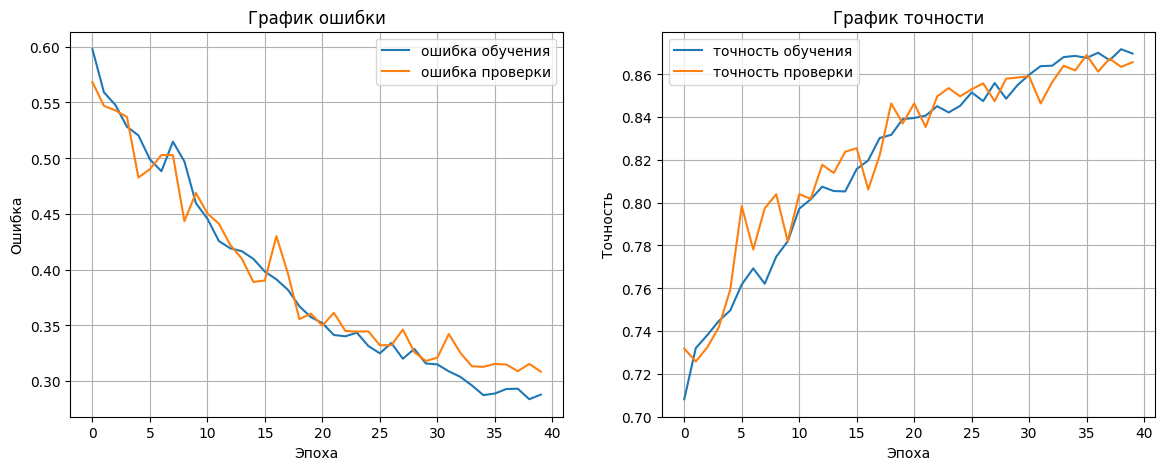

BusNet(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=9600, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.25, inplace=False)
    (4): Linear(in_features=256, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=2, bias=True)
  )
)
Всего параметров: 2474434
Обучаемых параметров: 2474434


In [7]:
bus_model.plot_history(history)
bus_model.summary()


In [8]:
# Сохранение обученной модели
# Файл появится слева в Colab во вкладке файлов.
torch.save(bus_model.model.state_dict(), 'bus_passenger_model_pytorch.pth')
print('Модель сохранена в файл bus_passenger_model_pytorch.pth')


Модель сохранена в файл bus_passenger_model_pytorch.pth
